# CLIP: Connecting Text and Images

In [13]:
from urllib.request import urlopen
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
from IPython.display import display
from google.colab import userdata

In [2]:
from huggingface_hub import login
login()

In [3]:
# puppy image and text
puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")
caption = "a puppy playing in the snow"
# car image and text
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/refs/heads/main/chapter09/images/car.png"
image_two = Image.open(urlopen(car_path)).convert("RGB")
caption_two = "Adam Standke a international man of mystery with great taste driving a supercar in the Swiss Alps"
# cat image and text
cat_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/refs/heads/main/chapter09/images/cat.png"
image_three = Image.open(urlopen(cat_path)).convert("RGB")
caption_three = "An angry cat who is owned by a blonde girl who lives next door nammed Sam"

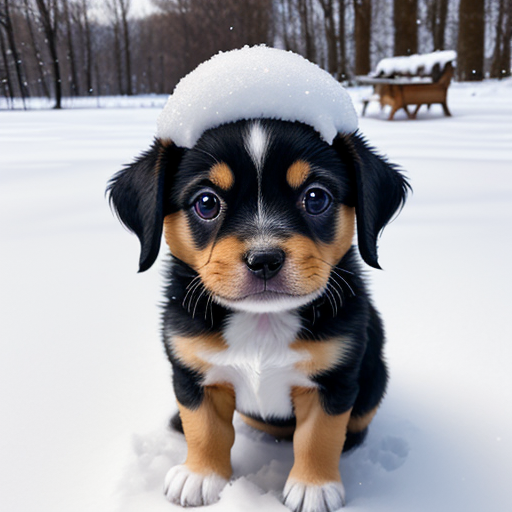

In [4]:
image

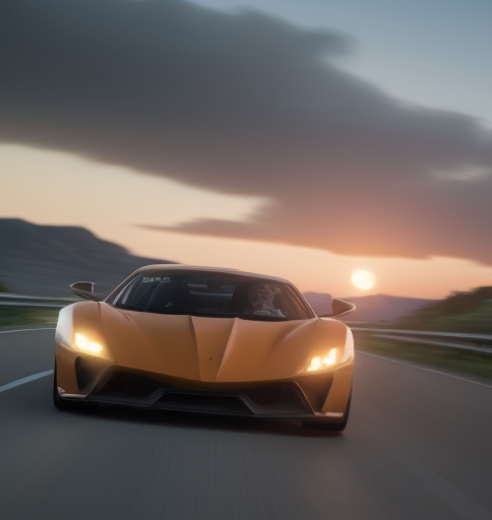

In [5]:
image_two

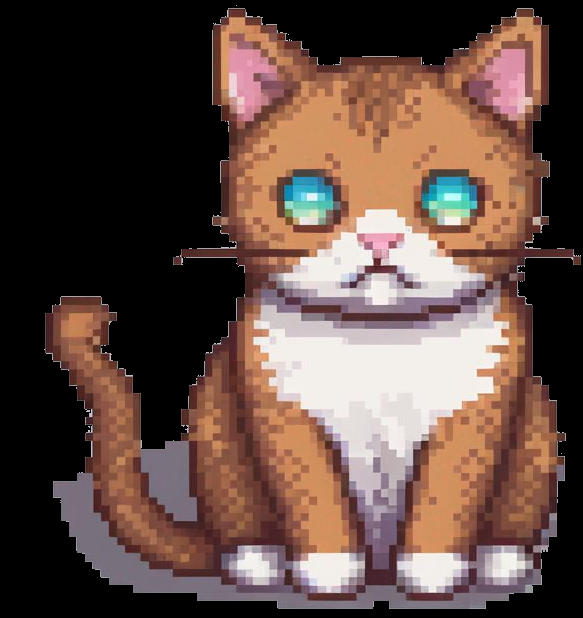

In [6]:
image_three

In [7]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel

In [14]:
model_id = "openai/clip-vit-base-patch32"
access_code = userdata.get('Multi')

In [15]:
# Load a tokenizer to preprocess the text
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id, token=access_code)

# Load a processor to preprocess the images
clip_processor = CLIPProcessor.from_pretrained(model_id, token=access_code)

# Main model for generating text and image embeddings
model = CLIPModel.from_pretrained(model_id, token=access_code)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [16]:
# Tokenize the text
dog_input = clip_tokenizer(caption, return_tensors="pt")
print(dog_input)
Adam_car = clip_tokenizer(caption_two , return_tensors="pt")
print(Adam_car)
SammyCat = clip_tokenizer(caption_three, return_tensors="pt")
print(SammyCat)

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}
{'input_ids': tensor([[49406,  4944,  1819,   618,   320,  2436,   786,   539,  6711,   593,
           830,  5219,  4161,   320, 27021,   530,   518,  9287, 18191, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
{'input_ids': tensor([[49406,   550,  9054,  2368,   822,   533,  8536,   638,   320, 10711,
          1611,   822,  3247,  1131,  2489,  1410,  2177,  3730, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [17]:
# Convert our input back to tokens
print(clip_tokenizer.convert_ids_to_tokens(dog_input["input_ids"][0]))
# Convert our input back to tokens
print(clip_tokenizer.convert_ids_to_tokens(Adam_car["input_ids"][0]))
# Convert our input back to tokens
clip_tokenizer.convert_ids_to_tokens(SammyCat["input_ids"][0])

['<|startoftext|>', 'a</w>', 'puppy</w>', 'playing</w>', 'in</w>', 'the</w>', 'snow</w>', '<|endoftext|>']
['<|startoftext|>', 'adam</w>', 'stand', 'ke</w>', 'a</w>', 'international</w>', 'man</w>', 'of</w>', 'mystery</w>', 'with</w>', 'great</w>', 'taste</w>', 'driving</w>', 'a</w>', 'supercar</w>', 'in</w>', 'the</w>', 'swiss</w>', 'alps</w>', '<|endoftext|>']


['<|startoftext|>',
 'an</w>',
 'angry</w>',
 'cat</w>',
 'who</w>',
 'is</w>',
 'owned</w>',
 'by</w>',
 'a</w>',
 'blonde</w>',
 'girl</w>',
 'who</w>',
 'lives</w>',
 'next</w>',
 'door</w>',
 'nam',
 'med</w>',
 'sam</w>',
 '<|endoftext|>']

In [18]:
# Create a text embedding
text_embedding = model.get_text_features(**dog_input)
text_embedding.shape
text_embedding_two = model.get_text_features(**Adam_car)
text_embedding_two.shape
text_embedding_three = model.get_text_features(**SammyCat)
text_embedding_three.shape

torch.Size([1, 512])

In [19]:
images= [image, image_two, image_three]

In [20]:
# Preprocess image
processed_image = clip_processor(
    text=None, images=images, return_tensors="pt"
)["pixel_values"]

processed_image.shape

torch.Size([3, 3, 224, 224])

In [21]:
# dog image
dog = processed_image[0, :, :, :]
processed_image[0, :, :, :].shape

torch.Size([3, 224, 224])

In [22]:
# me image
me = processed_image[1, :, :, :]
processed_image[1, :, :, :].shape

torch.Size([3, 224, 224])

In [23]:
# SammyCat
samCat = processed_image[2, :, :, :]
processed_image[2, :, :, :].shape

torch.Size([3, 224, 224])

In [24]:
# displaying processed pil images
trans = T.ToPILImage()

In [25]:
dog_display = trans(dog)
me_display = trans(me)
sam_display = trans(samCat)

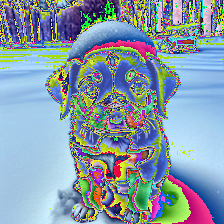

In [26]:
# display the PIL image
display(dog_display)

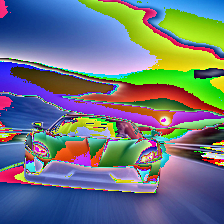

In [27]:
display(me_display)

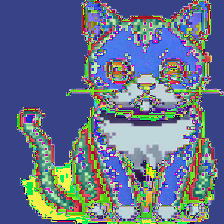

In [28]:
display(sam_display)

(-0.5, 223.5, 223.5, -0.5)

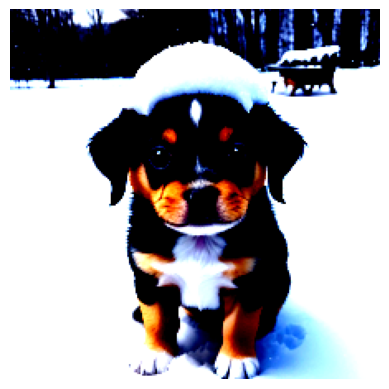

In [29]:
# Prepare image for visualization
img = dog.permute(*torch.arange(dog.ndim - 1, -1, -1))
img = np.einsum("ijk->jik", img)

# Visualize preprocessed image
plt.imshow(img)
plt.axis("off")

(-0.5, 223.5, 223.5, -0.5)

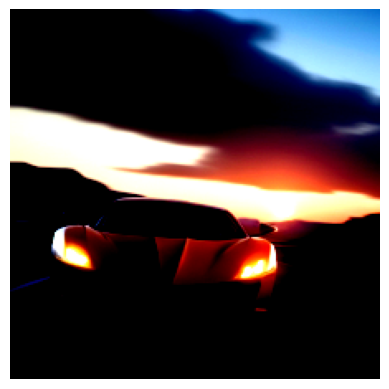

In [30]:
# Prepare image for visualization
img = me.permute(*torch.arange(me.ndim - 1, -1, -1))
img = np.einsum("ijk->jik", img)

# Visualize preprocessed image
plt.imshow(img)
plt.axis("off")

(-0.5, 223.5, 223.5, -0.5)

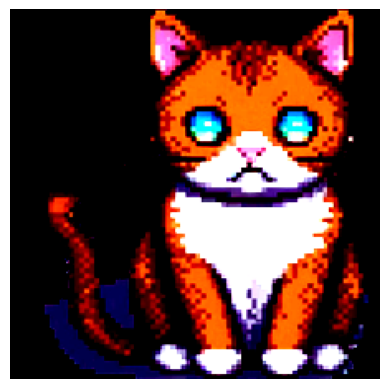

In [31]:
# Prepare image for visualization
img = samCat.permute(*torch.arange(samCat.ndim - 1, -1, -1))
img = np.einsum("ijk->jik", img)

# Visualize preprocessed image
plt.imshow(img)
plt.axis("off")

In [32]:
# Create the image embeddings
dog_embedding = model.get_image_features(dog.unsqueeze(0))
me_embedding = model.get_image_features(me.unsqueeze(0))
sam_embedding = model.get_image_features(samCat.unsqueeze(0))

In [33]:
# Normalize text embeddings
text_embedding /= text_embedding.norm(dim=-1, keepdim=True) # dog
text_embedding_two /= text_embedding_two.norm(dim=-1, keepdim=True) # me
text_embedding_three /= text_embedding_three.norm(dim=-1, keepdim=True) # Sam

# Normalize image embeddings
dog_embedding /= dog_embedding.norm(dim=-1, keepdim=True) # dog
me_embedding /= me_embedding.norm(dim=-1, keepdim=True) # me
sam_embedding /= sam_embedding.norm(dim=-1, keepdim=True) # Sam

# Calculate dog similarity
text_embedd = text_embedding.detach().numpy() # dog text
dog_embedd = dog_embedding.detach().numpy() # dog image
print(np.dot(text_embedd, dog_embedd.T))

me_embedding = me_embedding.detach().numpy()
print(np.dot(text_embedd, me_embedding.T)) # dog text/me image

sam_embedding = sam_embedding.detach().numpy()
print(np.dot(text_embedd, sam_embedding.T)) # dog text/sam the cat image


[[0.33149636]]
[[0.076222]]
[[0.14878336]]


# BLIP-2: Making Text Generation Models Multimodal


---



In [35]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch

# Load processor and main model
blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b", token=access_code)
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    token=access_code
)

# Send the model to GPU to speed up inference
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Blip2ForConditionalGeneration(
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((

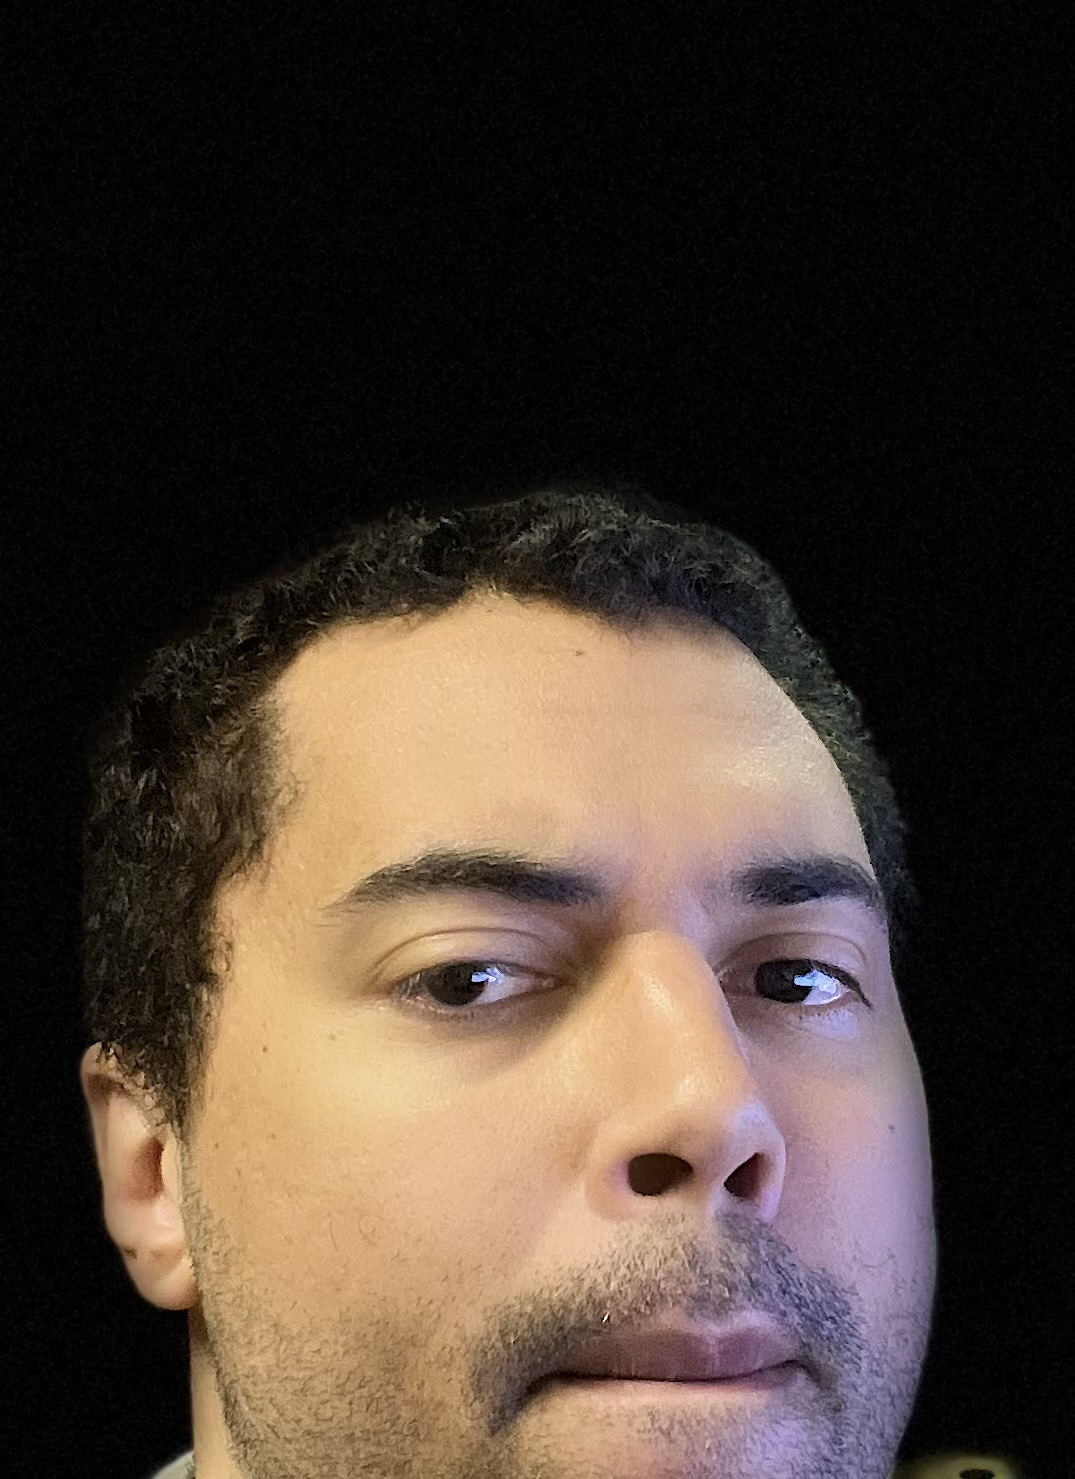

In [67]:
# orginal image
me_path = "https://raw.githubusercontent.com/AdamClarkStandke/GenerativeDeepLearning/refs/heads/main/IMG_0563.jpg"
image = Image.open(urlopen(me_path)).convert("RGB")
image

In [69]:
print(image.width)
print(image.height)

1075
1479


In [70]:
# Preprocess the image to be used by the BLIP 2 model
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
print(inputs["pixel_values"])
print(inputs["pixel_values"].shape)

tensor([[[[-1.7627, -1.7627, -1.7480,  ..., -1.7627, -1.7480, -1.7334],
          [-1.7480, -1.7480, -1.7480,  ..., -1.7480, -1.7480, -1.7197],
          [-1.7334, -1.7480, -1.7480,  ..., -1.7334, -1.7334, -1.7480],
          ...,
          [-1.7627, -1.7627, -1.7627,  ..., -1.7627, -1.7334, -1.7197],
          [-1.7480, -1.7627, -1.7480,  ..., -1.7334, -1.7480, -1.6904],
          [-1.7627, -1.7480, -1.7627,  ..., -1.7627, -1.7197, -1.7051]],

         [[-1.7217, -1.7217, -1.7070,  ..., -1.7217, -1.7070, -1.6924],
          [-1.7070, -1.7070, -1.7070,  ..., -1.7070, -1.7070, -1.6768],
          [-1.6924, -1.7070, -1.7070,  ..., -1.6924, -1.6924, -1.7070],
          ...,
          [-1.7217, -1.7217, -1.7217,  ..., -1.7217, -1.6924, -1.6768],
          [-1.7070, -1.7217, -1.7070,  ..., -1.6924, -1.7070, -1.6475],
          [-1.7217, -1.7070, -1.7217,  ..., -1.7217, -1.6768, -1.6621]],

         [[-1.4521, -1.4521, -1.4375,  ..., -1.4521, -1.4375, -1.4229],
          [-1.4375, -1.4375, -

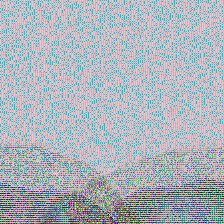

In [71]:
# processed image that is feed into Blip 2 model for text generation
Image.fromarray(inputs["pixel_values"].squeeze(0).permute(1,2, 0).cpu().numpy(), "RGB")

In [72]:
# Generate image ids to be passed to the decoder (LLM)
generated_ids = model.generate(**inputs, max_new_tokens=20)

# Generate text from the image ids
generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

'a man with a beard and a white shirt'